In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df= pd.read_csv("SuperStoreOrders.csv")

In [5]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [7]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [8]:
df['order_date']=pd.to_datetime(df['order_date'], dayfirst=True, format='mixed')

In [9]:
df['ship_date']=pd.to_datetime(df['ship_date'], dayfirst=True, format='mixed')

In [10]:
df['sales']=df['sales'].str.replace(',','')

In [11]:
df['sales']=pd.to_numeric(df['sales'])

In [12]:
df.duplicated().sum()

0

In [13]:
df["shipping_days"] = (df["ship_date"] - df["order_date"]).dt.days

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  int64         
 15  qu

## Demand 
### Top ctegories by Quantity

In [15]:
top_categories= df.groupby('category')['quantity'].sum().sort_values(ascending=False)

In [16]:
print(top_categories)

category
Office Supplies    108182
Technology          35176
Furniture           34954
Name: quantity, dtype: int64


### Top sub category by Quantity

In [17]:
top_sub_categories= (df.groupby(['sub_category','category'])['quantity'].sum().sort_values(ascending=False).head(10))

In [18]:
print(top_sub_categories)

sub_category  category       
Binders       Office Supplies    21429
Storage       Office Supplies    16917
Art           Office Supplies    16301
Paper         Office Supplies    12822
Chairs        Furniture          12336
Phones        Technology         11870
Furnishings   Furniture          11225
Accessories   Technology         10946
Labels        Office Supplies     9322
Supplies      Office Supplies     8543
Name: quantity, dtype: int64


### Top products by Quantity

In [19]:
top_products= df.groupby(['product_name','sub_category','category'])['quantity'].sum().sort_values(ascending=False).head(10)

In [20]:
top_products

product_name                           sub_category  category       
Cardinal Index Tab, Clear              Binders       Office Supplies    337
Eldon File Cart, Single Width          Storage       Office Supplies    321
Rogers File Cart, Single Width         Storage       Office Supplies    262
Sanford Pencil Sharpener, Water Color  Art           Office Supplies    259
Stockwell Paper Clips, Assorted Sizes  Fasteners     Office Supplies    253
Avery Index Tab, Clear                 Binders       Office Supplies    252
Ibico Index Tab, Clear                 Binders       Office Supplies    251
Smead File Cart, Single Width          Storage       Office Supplies    250
Stanley Pencil Sharpener, Water Color  Art           Office Supplies    242
Acco Index Tab, Clear                  Binders       Office Supplies    228
Name: quantity, dtype: int64

## Sales over time trend

In [21]:
sales_trend= df.groupby('order_date')['sales'].sum()

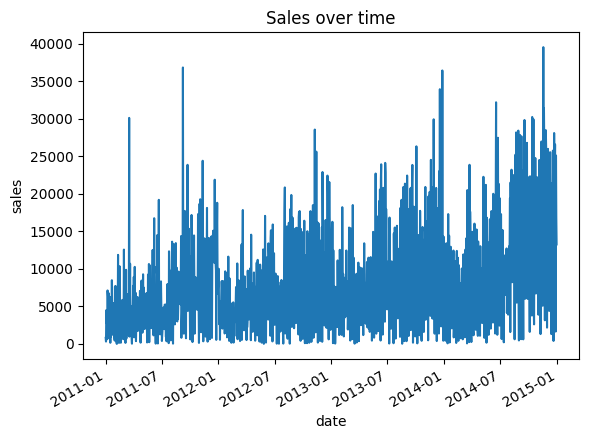

In [22]:
sales_trend.plot()
plt.title('Sales over time')
plt.ylabel('sales')
plt.xlabel('date')
plt.show()

In [23]:
sales_trendByYear= df.groupby('year')['sales'].sum().reset_index()

In [24]:
sales_trendByYear

,year,sales
0,2011,2259511
1,2012,2677493
2,2013,3405860
3,2014,4300041


### sales over time by year

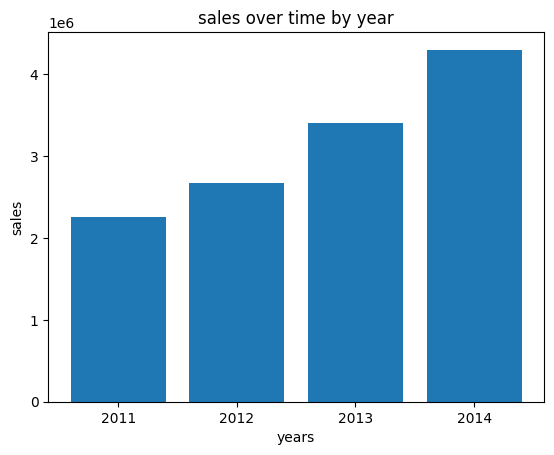

In [25]:
plt.figure()
plt.bar(sales_trendByYear['year'],sales_trendByYear['sales'])
plt.title("sales over time by year")
plt.ylabel('sales')
plt.xlabel('years')
plt.xticks(sales_trendByYear['year'])
plt.show()

### sales over time by month

In [26]:
monthly_sales= (
    df.set_index('order_date').resample('ME')['year'].sum()
)

Text(0, 0.5, 'sales')

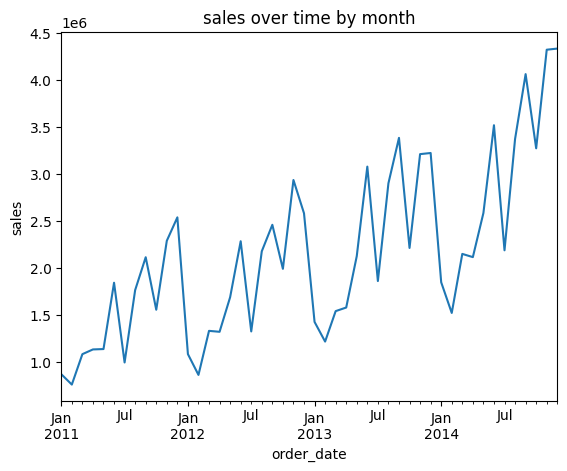

In [27]:
monthly_sales.plot()
plt.title("sales over time by month")
plt.ylabel('sales')

##### does High quantity means high sales? 

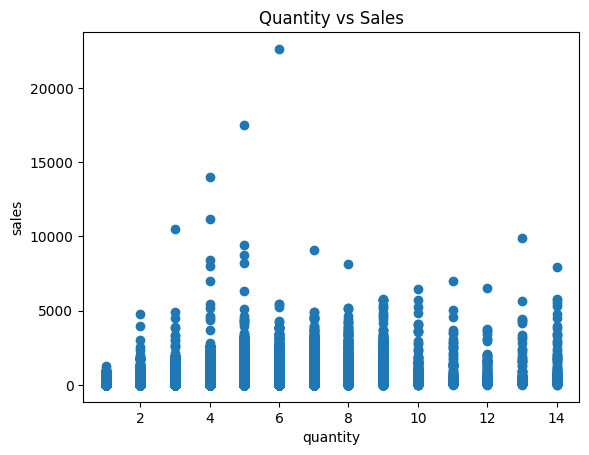

In [28]:
plt.scatter(df['quantity'],df['sales'])
plt.title('Quantity vs Sales')
plt.ylabel('sales')
plt.xlabel('quantity')
plt.show()

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  int64         
 15  qu

In [30]:
summary_quantity= df.groupby(['product_name', 'category', 'sub_category']).agg({'quantity': 'sum', 'sales': 'sum', 'profit': 'sum'}).sort_values(by='quantity', ascending=False)
summary_quantity.head(10)

,,,quantity,sales,profit
product_name,category,sub_category,,,
"Cardinal Index Tab, Clear",Office Supplies,Binders,337,1922,556.3702
"Eldon File Cart, Single Width",Office Supplies,Storage,321,34392,4238.8887
"Rogers File Cart, Single Width",Office Supplies,Storage,262,29467,2394.8953
"Sanford Pencil Sharpener, Water Color",Office Supplies,Art,259,5581,601.9441
"Stockwell Paper Clips, Assorted Sizes",Office Supplies,Fasteners,253,2404,251.2878
"Avery Index Tab, Clear",Office Supplies,Binders,252,1314,221.5388
"Ibico Index Tab, Clear",Office Supplies,Binders,251,1808,125.6411
"Smead File Cart, Single Width",Office Supplies,Storage,250,25397,-237.6692
"Stanley Pencil Sharpener, Water Color",Office Supplies,Art,242,5537,125.5390


In [31]:
summary_profit= df.groupby(['product_name', 'category', 'sub_category']).agg({'quantity': 'sum', 'sales': 'sum', 'profit': 'sum'}).sort_values(by='profit', ascending=False)
summary_profit.head(10)

,,,quantity,sales,profit
product_name,category,sub_category,,,
Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,20,61600,25199.9280
"Cisco Smart Phone, Full Size",Technology,Phones,139,76441,17238.5206
"Motorola Smart Phone, Full Size",Technology,Phones,134,73159,17027.1130
"Hoover Stove, Red",Office Supplies,Appliances,62,31664,11807.9690
"Sauder Classic Bookcase, Traditional",Furniture,Bookcases,113,39110,10672.0730
"Harbour Creations Executive Leather Armchair, Adjustable",Furniture,Chairs,142,50120,10427.3260
"Nokia Smart Phone, Full Size",Technology,Phones,147,71904,9938.1955
"Cisco Smart Phone, with Caller ID",Technology,Phones,85,43124,9786.6408
"Nokia Smart Phone, with Caller ID",Technology,Phones,96,47880,9465.3257


In [32]:
summary_sales= df.groupby(['product_name', 'category', 'sub_category']).agg({'quantity': 'sum', 'sales': 'sum', 'profit': 'sum'}).sort_values(by='sales', ascending=False)
summary_sales.head(10)

,,,quantity,sales,profit
product_name,category,sub_category,,,
"Apple Smart Phone, Full Size",Technology,Phones,171,86936,5921.5786
"Cisco Smart Phone, Full Size",Technology,Phones,139,76441,17238.5206
"Motorola Smart Phone, Full Size",Technology,Phones,134,73159,17027.1130
"Nokia Smart Phone, Full Size",Technology,Phones,147,71904,9938.1955
Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,20,61600,25199.9280
"Hon Executive Leather Armchair, Adjustable",Furniture,Chairs,169,58200,5997.2541
"Office Star Executive Leather Armchair, Adjustable",Furniture,Chairs,141,50667,4710.9840
"Harbour Creations Executive Leather Armchair, Adjustable",Furniture,Chairs,142,50120,10427.3260
"Samsung Smart Phone, Cordless",Technology,Phones,108,48654,-198.0900


In [33]:
from ydata_profiling import ProfileReport


In [34]:
df_report = df.profile_report(
    explorative=True, html={"style": {"full_width": True}}
)
df_report

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [43]:
print(df[['discount', 'profit']].corr())

          discount    profit
discount  1.000000 -0.316375
profit   -0.316375  1.000000


## Finds:
##### - Office Supplies category shows the highest demand in terms of quantity particularly in sub-categories such as Binders and Storage
##### - technology especially the Phones sub-category, generates the highest sales and profit, despite not always having the highest quantity.
##### - There is a weak or inconsistent relationship between demand and profitability
##### - Sales show a steady upward trend over time
##### - high-demand products are not always the most profitable. Some high-volume items generate low margins or even losses, while certain low-demand products contribute significantly to overall profit. This indicates that inventory decisions should not rely solely on demand but also consider product profitability.
##### - A moderate negative correlation (-0.32) between discount and profit indicates that higher discount levels are associated with reduced profitability, suggesting that current discount strategies may be eroding margins, particularly for certain product categories.
##### - Despite an overall increase in profit over time, around 25% of transactions are either unprofitable or break-even. This suggests potential inefficiencies in pricing, discounting, or cost management, particularly for certain products or categories.


In [35]:
negative_df = df[df['profit'] < 0]


In [36]:
neg_count_by_category = (
    negative_df.groupby('category')['profit']
    .count()
    .sort_values(ascending=False)
)

print(neg_count_by_category)

category
Office Supplies    7003
Furniture          3116
Technology         2424
Name: profit, dtype: int64


In [37]:
neg_count_by_subcategory = (
    negative_df.groupby(['sub_category', 'category', 'discount'])['profit']
    .count()
    .sort_values(ascending=False).head(10)
)

print(neg_count_by_subcategory)

sub_category  category         discount
Binders       Office Supplies  0.7         588
Storage       Office Supplies  0.4         286
Phones        Technology       0.4         279
Furnishings   Furniture        0.4         258
Chairs        Furniture        0.2         251
Storage       Office Supplies  0.1         242
Furnishings   Furniture        0.6         241
Art           Office Supplies  0.6         236
Binders       Office Supplies  0.8         233
Storage       Office Supplies  0.6         224
Name: profit, dtype: int64


##### high discount levels (up to 80%) are frequently applied, particularly in Office Supplies sub-categories such as Binders and Storage. This suggests that sales volume in these categories may be driven by aggressive discounting
####  Frequent high discounting, especially in Office Supplies, appears to drive sales volume while reducing profit margins, highlighting a trade-off between demand and profitability. This suggests that demand-driven inventory strategies may lead to over-prioritizing low-margin or loss-making products.”

In [38]:
df[df['discount'] > 0.5]['profit'].mean()


-98.89301480345158

In [39]:
df[df['discount'] <= 0.5]['profit'].mean()


39.93413300734326

#### While discounting appears to drive sales volume, discounts above 50% lead to consistent losses, with an average negative profit per transaction. This suggests that current discount strategies may be prioritizing sales growth at the expense of profitability.

### The business is growing in sales and profit overall, but underlying inefficiencies in discounting and inventory prioritization suggest that profitability is being partially driven by high-volume, low-margin transactions rather than sustainable value creation

In [40]:
df.to_csv("SuperStoreOrders_afterEDA.csv", index=False)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  int64         
 15  qu

In [42]:
df[['discount', 'profit']].describe()

,discount,profit
count,51290.000000,51290.000000
mean,0.142908,28.641740
std,0.212280,174.424113
min,0.000000,-6599.978000
25%,0.000000,0.000000
50%,0.000000,9.240000
75%,0.200000,36.810000
max,0.850000,8399.976000
